In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

# Task 1: Baseline with Single Models


In [2]:
# Task 1: Baseline with Single Models

# Load the Wine Quality dataset and create a binary target
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"   # Dataset URL
wine = pd.read_csv(url, sep=";")     # Read CSV file using semicolon separator

# Create binary target: 1 = good quality wine (quality >= 7), 0 = not good
wine["quality_label"] = (wine["quality"] >= 7).astype(int)

# Explore the dataset: shape, features, class distribution
print("Dataset shape:", wine.shape)   # Print number of rows and columns
print("\nFeature columns:")
print(wine.columns.tolist())          # Print all column names

print("\nClass distribution:")
print(wine["quality_label"].value_counts())   # Count each class

print("\nClass distribution (percentage):")
print(wine["quality_label"].value_counts(normalize=True))   # Class percentages

# Separate features and target
X = wine.drop(["quality", "quality_label"], axis=1)   # Remove original and binary target columns
y = wine["quality_label"]                             # Define binary target

# Split into training and test sets (80/20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% test data
    stratify=y,             # Preserve class ratio
    random_state=42         # Reproducibility
)

# Scale features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()                       # Initialize scaler
X_train_scaled = scaler.fit_transform(X_train) # Fit scaler only on training data
X_test_scaled = scaler.transform(X_test)       # Apply same scaling to test data

# Fit three baseline models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Initialize models
dt = DecisionTreeClassifier(random_state=42)                 # Decision Tree baseline
lr = LogisticRegression(max_iter=1000, random_state=42)      # Logistic Regression baseline
knn = KNeighborsClassifier()                                 # KNN baseline

# Train models
dt.fit(X_train, y_train)                 # Tree uses unscaled data
lr.fit(X_train_scaled, y_train)          # Logistic Regression uses scaled data
knn.fit(X_train_scaled, y_train)         # KNN uses scaled data

# Make predictions
dt_pred = dt.predict(X_test)             # Tree predictions
lr_pred = lr.predict(X_test_scaled)      # Logistic Regression predictions
knn_pred = knn.predict(X_test_scaled)    # KNN predictions

# Report accuracy and F1 score
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "F1 Score": [
        f1_score(y_test, dt_pred, average="binary"),
        f1_score(y_test, lr_pred, average="binary"),
        f1_score(y_test, knn_pred, average="binary")
    ]
})

# Show results table
print("\nBaseline Model Results:")
print(results)

Dataset shape: (1599, 13)

Feature columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'quality_label']

Class distribution:
quality_label
0    1382
1     217
Name: count, dtype: int64

Class distribution (percentage):
quality_label
0    0.86429
1    0.13571
Name: proportion, dtype: float64

Baseline Model Results:
                 Model  Accuracy  F1 Score
0        Decision Tree   0.90000  0.644444
1  Logistic Regression   0.89375  0.484848
2                  KNN   0.89375  0.514286


## Baseline Model Comparison

In these baseline results, I see that all three models give good accuracy, but accuracy alone is not enough here because the dataset is imbalanced and most wines belong to class 0. Because of that, I also look at the F1 score to understand how well the models detect good quality wines in class 1. From the results, I see that the Decision Tree model performs better than the other two models, especially in F1 score. Logistic Regression and KNN also work well, but they are weaker when predicting the minority class. I think this happens because the relationships between wine features are not fully linear, and tree models can follow these patterns more easily. These baseline results are important for me because they show the starting point before using ensemble methods, and later I can compare if ensemble models improve the prediction results.

# Task 2: Bagging & Random Forest


Bagging and Random Forest Results:
           Model  OOB Score  Accuracy  F1 Score
0        Bagging   0.897576   0.93750  0.736842
1  Random Forest   0.899140   0.94375  0.750000

Comparison with Single Decision Tree:
           Model  Accuracy  F1 Score
0  Decision Tree   0.90000  0.644444
1        Bagging   0.93750  0.736842
2  Random Forest   0.94375  0.750000


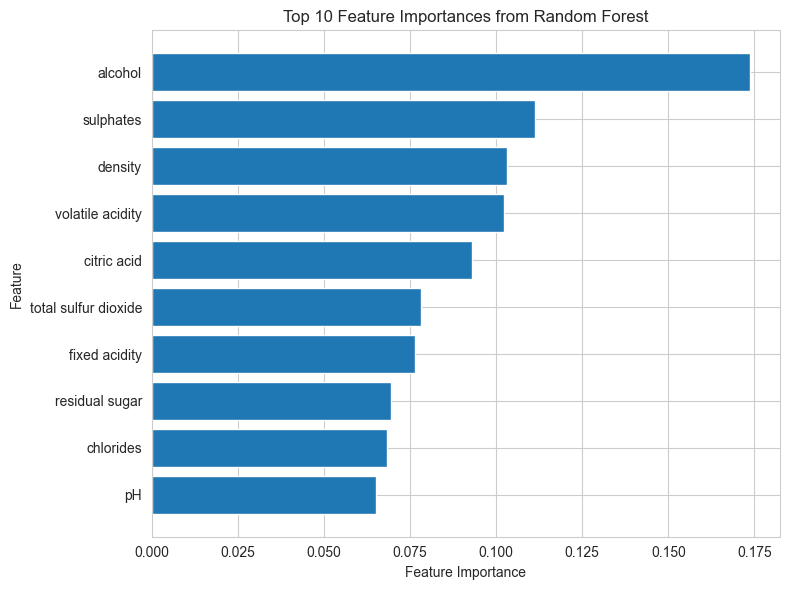


Top 10 Most Important Features:
                 Feature  Importance
10               alcohol    0.173743
9              sulphates    0.111262
7                density    0.103162
1       volatile acidity    0.102414
2            citric acid    0.092871
6   total sulfur dioxide    0.078284
0          fixed acidity    0.076361
3         residual sugar    0.069339
4              chlorides    0.068312
8                     pH    0.065180


In [4]:
# Fit a BaggingClassifier with a DecisionTreeClassifier as the base estimator
# (n_estimators=100, oob_score=True, random_state=42).

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),  # Use Decision Tree as the base model
    n_estimators=100,                                   # Train 100 trees in the bagging ensemble
    oob_score=True,                                     # Enable out-of-bag evaluation
    random_state=42                                     # Fix random state for reproducibility
)

bagging.fit(X_train, y_train)                           # Train Bagging model on training data
bagging_pred = bagging.predict(X_test)                 # Make predictions on test data

# Fit a RandomForestClassifier
# (n_estimators=100, oob_score=True, random_state=42).

rf = RandomForestClassifier(
    n_estimators=100,                                   # Train 100 trees in the random forest
    oob_score=True,                                     # Enable out-of-bag evaluation
    random_state=42                                     # Fix random state for reproducibility
)

rf.fit(X_train, y_train)                                # Train Random Forest model on training data
rf_pred = rf.predict(X_test)                            # Make predictions on test data

# For both models, report:
# Out-of-bag (OOB) score
# Test accuracy and F1 score.

bagging_oob = bagging.oob_score_                        # Store OOB score for Bagging
rf_oob = rf.oob_score_                                  # Store OOB score for Random Forest

bagging_acc = accuracy_score(y_test, bagging_pred)      # Calculate Bagging test accuracy
rf_acc = accuracy_score(y_test, rf_pred)                # Calculate Random Forest test accuracy

bagging_f1 = f1_score(y_test, bagging_pred, average="binary")  # Calculate Bagging F1 score
rf_f1 = f1_score(y_test, rf_pred, average="binary")            # Calculate Random Forest F1 score

# Organize model evaluation results in a table.

ensemble_results = pd.DataFrame({
    "Model": ["Bagging", "Random Forest"],              # Model names
    "OOB Score": [bagging_oob, rf_oob],                # OOB scores
    "Accuracy": [bagging_acc, rf_acc],                 # Test accuracies
    "F1 Score": [bagging_f1, rf_f1]                    # Test F1 scores
})

print("Bagging and Random Forest Results:")            # Print table title
print(ensemble_results)                                # Display results table

# Compare: How does bagging improve over the single Decision Tree from Task 1?
# Add the Decision Tree baseline from Task 1 into a comparison table.

comparison_with_baseline = pd.DataFrame({
    "Model": ["Decision Tree", "Bagging", "Random Forest"],     # Include baseline and ensemble models
    "Accuracy": [
        accuracy_score(y_test, dt_pred),                        # Decision Tree accuracy from Task 1
        bagging_acc,                                            # Bagging accuracy
        rf_acc                                                  # Random Forest accuracy
    ],
    "F1 Score": [
        f1_score(y_test, dt_pred, average="binary"),            # Decision Tree F1 from Task 1
        bagging_f1,                                             # Bagging F1
        rf_f1                                                   # Random Forest F1
    ]
})

print("\nComparison with Single Decision Tree:")       # Print comparison table title
print(comparison_with_baseline)                        # Display comparison table

# Plot the top 10 feature importances from the Random Forest as a horizontal bar chart.

importance_df = pd.DataFrame({
    "Feature": X.columns,                              # Store feature names
    "Importance": rf.feature_importances_              # Store importance scores from Random Forest
})

top10_importance = importance_df.sort_values(
    by="Importance", 
    ascending=False
).head(10)                                             # Select top 10 most important features

top10_importance = top10_importance.sort_values(
    by="Importance", 
    ascending=True
)                                                      # Sort again for better horizontal bar chart display

plt.figure(figsize=(8, 6))                             # Set figure size
plt.barh(top10_importance["Feature"], top10_importance["Importance"])  # Create horizontal bar chart
plt.xlabel("Feature Importance")                       # Label x-axis
plt.ylabel("Feature")                                  # Label y-axis
plt.title("Top 10 Feature Importances from Random Forest")  # Add chart title
plt.tight_layout()                                     # Adjust layout
plt.show()                                             # Display plot

# Which features matter most for predicting wine quality?
# Print the top 10 feature importance table for easier interpretation.

print("\nTop 10 Most Important Features:")             # Print title for top features
print(top10_importance.sort_values(by="Importance", ascending=False))   # Show most important features first

## Bagging and Random Forest Comparison

In this task, I compared Bagging and Random Forest with the single Decision Tree baseline from Task 1. From the results, I can see that both ensemble models improve the performance compared to one Decision Tree. The Decision Tree gave lower accuracy and F1 score, while Bagging increased both metrics because it combines many trees instead of depending on one tree only. Random Forest performed slightly better than Bagging in both accuracy and F1 score. I think this happens because Random Forest not only uses different bootstrap samples like Bagging, but also adds randomness in feature selection during each split, which makes the trees more different from each other and improves generalization. The OOB scores are also close to the test results, which shows that the models are stable and do not strongly overfit. In the feature importance plot, alcohol appears as the most important feature, followed by sulphates, density, and volatile acidity. This means these variables contribute more often to useful splits across many trees and have stronger influence on predicting wine quality.

# Task 3: Boosting


Boosting Model Results:
                  Model  Accuracy  F1 Score
0              AdaBoost  0.893750  0.433333
1     Gradient Boosting  0.915625  0.619718
2  HistGradientBoosting  0.946875  0.773333


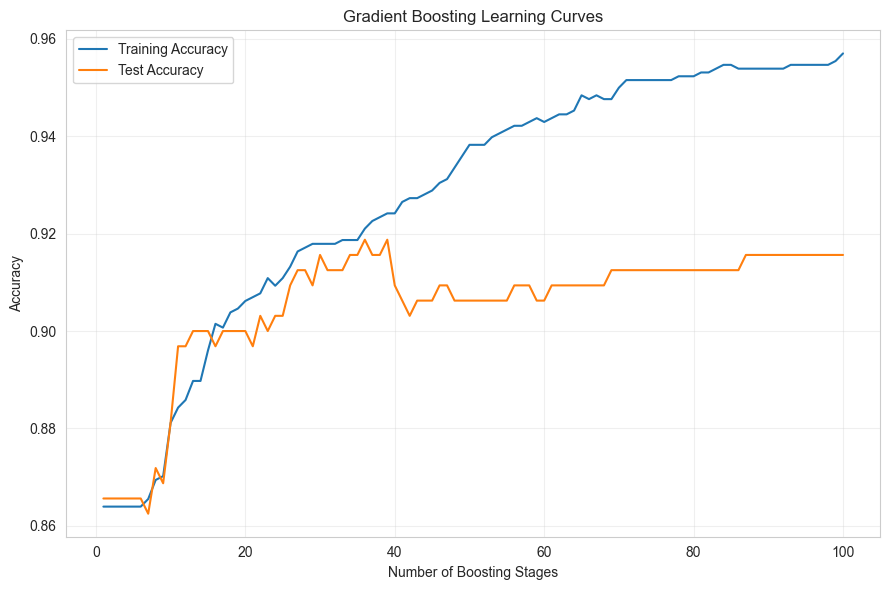


Gradient Boosting Learning Curve Summary:
Best test accuracy occurs at stage: 36
Best test accuracy: 0.9187
Final training accuracy: 0.9570
Final test accuracy: 0.9156


In [6]:
# Fit the following boosting models:
# AdaBoostClassifier(n_estimators=100, random_state=42)

ada = AdaBoostClassifier(
    n_estimators=100,      # Use 100 boosting rounds
    random_state=42        # Fix random state for reproducibility
)

ada.fit(X_train, y_train)  # Train AdaBoost on training data
ada_pred = ada.predict(X_test)  # Predict on test data

# GradientBoostingClassifier(n_estimators=100, random_state=42)

gb = GradientBoostingClassifier(
    n_estimators=100,      # Use 100 boosting stages
    random_state=42        # Fix random state for reproducibility
)

gb.fit(X_train, y_train)   # Train Gradient Boosting on training data
gb_pred = gb.predict(X_test)  # Predict on test data

# (Optional) HistGradientBoostingClassifier(max_iter=100, random_state=42)
# This is scikit-learn's faster histogram-based boosting implementation

hgb = HistGradientBoostingClassifier(
    max_iter=100,          # Use 100 boosting iterations
    random_state=42        # Fix random state for reproducibility
)

hgb.fit(X_train, y_train)  # Train HistGradientBoosting on training data
hgb_pred = hgb.predict(X_test)  # Predict on test data

# Report accuracy and F1 for each on the test set.

boosting_results = pd.DataFrame({
    "Model": ["AdaBoost", "Gradient Boosting", "HistGradientBoosting"],   # Model names
    "Accuracy": [
        accuracy_score(y_test, ada_pred),   # AdaBoost test accuracy
        accuracy_score(y_test, gb_pred),    # Gradient Boosting test accuracy
        accuracy_score(y_test, hgb_pred)    # HistGradientBoosting test accuracy
    ],
    "F1 Score": [
        f1_score(y_test, ada_pred, average="binary"),   # AdaBoost test F1
        f1_score(y_test, gb_pred, average="binary"),    # Gradient Boosting test F1
        f1_score(y_test, hgb_pred, average="binary")    # HistGradientBoosting test F1
    ]
})

print("Boosting Model Results:")   # Print table title
print(boosting_results)            # Display boosting results

# Learning curves:
# For GradientBoostingClassifier, use staged_predict to compute training and test accuracy
# at each boosting stage (1 to 100 estimators).

train_accuracies = []   # Create empty list for training accuracy values
test_accuracies = []    # Create empty list for test accuracy values

for y_train_stage_pred in gb.staged_predict(X_train):   # Predict training set after each boosting stage
    train_acc = accuracy_score(y_train, y_train_stage_pred)   # Compute training accuracy at this stage
    train_accuracies.append(train_acc)                        # Store training accuracy

for y_test_stage_pred in gb.staged_predict(X_test):     # Predict test set after each boosting stage
    test_acc = accuracy_score(y_test, y_test_stage_pred)     # Compute test accuracy at this stage
    test_accuracies.append(test_acc)                         # Store test accuracy

# Plot both curves on the same figure.

plt.figure(figsize=(9, 6))   # Set figure size
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Training Accuracy")  # Plot training curve
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, label="Test Accuracy")        # Plot test curve

plt.xlabel("Number of Boosting Stages")   # Label x-axis
plt.ylabel("Accuracy")                    # Label y-axis
plt.title("Gradient Boosting Learning Curves")   # Add chart title
plt.legend()                              # Show legend
plt.grid(True, alpha=0.3)                 # Add light grid
plt.tight_layout()                        # Adjust layout
plt.show()                                # Display plot

# At what point does the model start to overfit (if at all)?
# A simple way to inspect this is to find the stage with the best test accuracy.

best_stage = test_accuracies.index(max(test_accuracies)) + 1   # Find stage number with highest test accuracy
best_test_accuracy = max(test_accuracies)                      # Best test accuracy value
final_train_accuracy = train_accuracies[-1]                    # Training accuracy at final stage
final_test_accuracy = test_accuracies[-1]                      # Test accuracy at final stage

print("\nGradient Boosting Learning Curve Summary:")   # Print summary title
print(f"Best test accuracy occurs at stage: {best_stage}")   # Print best stage
print(f"Best test accuracy: {best_test_accuracy:.4f}")       # Print best test accuracy
print(f"Final training accuracy: {final_train_accuracy:.4f}")  # Print final training accuracy
print(f"Final test accuracy: {final_test_accuracy:.4f}")       # Print final test accuracy

## AdaBoost and Gradient Boosting Comparison

In these results, I can see that Gradient Boosting performs better than AdaBoost on this dataset because it gives both higher accuracy and a much stronger F1 score. AdaBoost also improves learning by building models step by step, but its performance is weaker here, especially for detecting the minority class. The main difference is that AdaBoost gives more attention to samples that were classified incorrectly in previous steps, while Gradient Boosting builds each new model to correct the residual errors left by the previous model. This makes Gradient Boosting more flexible because it improves prediction gradually in a more detailed way. From the learning curve, I see that test accuracy reaches its best value around stage 36, and after that the training accuracy continues to increase while test accuracy stays almost stable, which suggests that slight overfitting starts after that point. If I need a simpler boosting model, I may choose AdaBoost, but if I want stronger predictive performance, Gradient Boosting is usually a better choice. In this task, HistGradientBoosting gives the strongest result, which shows that the histogram-based implementation handles this dataset very efficiently.

# Task 4: Stacking & Voting


In [7]:
# Voting classifier:
# Select the 3 best-performing models from Tasks 1–3.
# Build a VotingClassifier with voting="soft".

voting = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),            # Random Forest base model
        ("bagging", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=100,
            random_state=42
        )),                                                                            # Bagging base model
        ("hgb", HistGradientBoostingClassifier(
            max_iter=100,
            random_state=42
        ))                                                                             # HistGradientBoosting base model
    ],
    voting="soft"                                                                      # Use probability averaging
)

# Train VotingClassifier
voting.fit(X_train, y_train)

# Predict on test set
voting_pred = voting.predict(X_test)

# Report accuracy and F1 on the test set.

voting_acc = accuracy_score(y_test, voting_pred)                        # Voting accuracy
voting_f1 = f1_score(y_test, voting_pred, average="binary")             # Voting F1 score

print("Voting Classifier Results:")
print("Accuracy:", voting_acc)
print("F1 Score:", voting_f1)

# Stacking classifier:
# Using the same 3 base models, build a StackingClassifier
# with LogisticRegression() as the final_estimator.

stacking = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),            # Random Forest base model
        ("bagging", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=100,
            random_state=42
        )),                                                                            # Bagging base model
        ("hgb", HistGradientBoostingClassifier(
            max_iter=100,
            random_state=42
        ))                                                                             # HistGradientBoosting base model
    ],
    final_estimator=LogisticRegression(max_iter=1000),                                # Meta learner
    cv=5                                                                               # Use 5-fold CV internally
)

# Train StackingClassifier
stacking.fit(X_train, y_train)

# Predict on test set
stacking_pred = stacking.predict(X_test)

# Report accuracy and F1 on the test set.

stacking_acc = accuracy_score(y_test, stacking_pred)                  # Stacking accuracy
stacking_f1 = f1_score(y_test, stacking_pred, average="binary")       # Stacking F1 score

print("\nStacking Classifier Results:")
print("Accuracy:", stacking_acc)
print("F1 Score:", stacking_f1)

# Final comparison table:
# Create a comprehensive DataFrame comparing all models from the entire lab
# Sort by F1 descending.

final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "KNN",
        "Bagging",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "HistGradientBoosting",
        "Voting",
        "Stacking"
    ],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, bagging_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, hgb_pred),
        voting_acc,
        stacking_acc
    ],
    "F1 Score": [
        f1_score(y_test, dt_pred, average="binary"),
        f1_score(y_test, lr_pred, average="binary"),
        f1_score(y_test, knn_pred, average="binary"),
        f1_score(y_test, bagging_pred, average="binary"),
        f1_score(y_test, rf_pred, average="binary"),
        f1_score(y_test, ada_pred, average="binary"),
        f1_score(y_test, gb_pred, average="binary"),
        f1_score(y_test, hgb_pred, average="binary"),
        voting_f1,
        stacking_f1
    ]
})

# Sort by F1 descending
final_results = final_results.sort_values(by="F1 Score", ascending=False)

print("\nFinal Comparison Table:")
print(final_results)

Voting Classifier Results:
Accuracy: 0.95
F1 Score: 0.7837837837837838

Stacking Classifier Results:
Accuracy: 0.940625
F1 Score: 0.7323943661971831

Final Comparison Table:
                  Model  Accuracy  F1 Score
8                Voting  0.950000  0.783784
7  HistGradientBoosting  0.946875  0.773333
4         Random Forest  0.943750  0.750000
3               Bagging  0.937500  0.736842
9              Stacking  0.940625  0.732394
0         Decision Tree  0.900000  0.644444
6     Gradient Boosting  0.915625  0.619718
2                   KNN  0.893750  0.514286
1   Logistic Regression  0.893750  0.484848
5              AdaBoost  0.893750  0.433333


## Final Conclusion

In the final comparison, I see that the Voting classifier gives the best result on this dataset because it has the highest accuracy and the highest F1 score among all models. This means that combining the strongest models with soft voting helps produce more balanced predictions than using one model alone. The improvement over single models is clearly visible because the baseline Decision Tree had a much lower F1 score, while the ensemble methods improved both overall accuracy and the ability to detect the minority class. I also notice that HistGradientBoosting and Random Forest perform very strongly, but Voting still gives the best final balance. At the same time, ensemble methods have some trade-offs because they need more training time, they are harder to interpret, and the full prediction process becomes more complex compared to a single model like Decision Tree. A single tree is easy to explain, but ensemble models usually generalize better and give more stable predictions. For a real wine quality prediction system, I would recommend the Voting classifier because it combines strong models and gives the best predictive performance while still remaining practical for structured tabular data.